In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("heart.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
X=df.drop("target",axis=1)
y=df["target"]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
dt_predictions=dt_model.predict(X_test)
print(dt_predictions)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0
 1 1 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0 0 1
 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0
 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 0 1
 1 1 0 1 1 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0]


In [12]:
from sklearn.metrics import accuracy_score
depths=[2,3,4,5,6,8,10,None]
for depth in depths:
    model=DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train,y_train)
    predictions=model.predict(X_test)
    accuracy=accuracy_score(y_test,predictions)
    print(f"Max Depth = {depth}, Accuracy = {accuracy:.4f}")

Max Depth = 2, Accuracy = 0.6780
Max Depth = 3, Accuracy = 0.7805
Max Depth = 4, Accuracy = 0.8000
Max Depth = 5, Accuracy = 0.8439
Max Depth = 6, Accuracy = 0.8829
Max Depth = 8, Accuracy = 0.9756
Max Depth = 10, Accuracy = 0.9854
Max Depth = None, Accuracy = 0.9854


In [13]:
print("Training Accuracy:", dt_model.score(X_train, y_train))
print("Testing Accuracy:", dt_model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9853658536585366


✅ Visualize the Decision Tree
✅ Understand every hyperparameter
✅ Tune the Decision Tree
✅ Perform Cross Validation
✅ Compare with the original Decision Tree

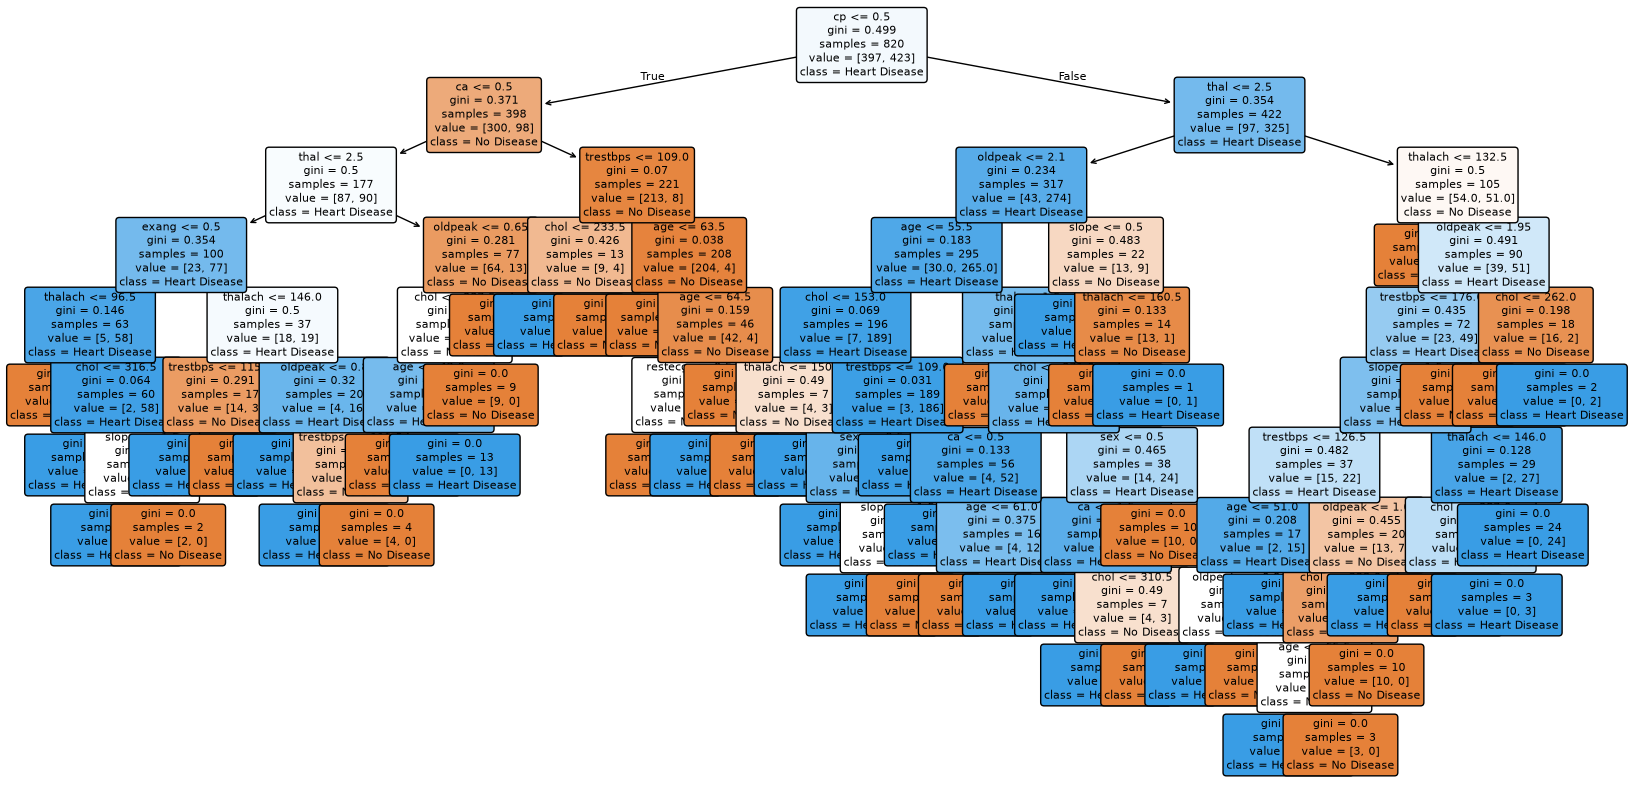

In [15]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Disease", "Heart Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [17]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(
    DecisionTreeClassifier(max_depth=10,random_state=42),
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print("Fold Accuracies:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Fold Accuracies: [1. 1. 1. 1. 1.]
Average Accuracy: 1.0
Standard Deviation: 0.0
